# Modelo ARIMA
En este notebook implementamos el modelo **ARIMA** (AutoRegressive Integrated Moving Average) para resolver el problema de predicción de ventas planteado.
El objetivo es utilizar los datos históricos para predecir las ventas diarias entre el **9 de noviembre y el 9 de diciembre de 2011**.
Evaluaremos el rendimiento utilizando la métrica **RMSE**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Cargamos los datos procesados y dividos
train_df = pd.read_csv('../../data/processed/train_val.csv', parse_dates=['Date'], index_col='Date')
test_df = pd.read_csv('../../data/processed/test.csv', parse_dates=['Date'], index_col='Date')

# Comprobamos que la frecuencia sea diaría
# Rellenamos huecos con 0 ventas si los hubiera
train_df = train_df.asfreq('D').fillna(0)
test_df = test_df.asfreq('D').fillna(0)

print(f"[INFO] Registros para entrenamiento: {len(train_df)}")
print(f"[INFO] Registros para evaluación (test): {len(test_df)}")

[INFO] Registros para entrenamiento: 342
[INFO] Registros para evaluación (test): 31


In [3]:
# Definimos la variable objetivo
y_train = train_df['Sales']
y_test = test_df['Sales']

# Preparamos la configuración del modelo ARIMA (p, d, q)
# p: periodos lag, d: diferenciación, q: media móvil
model = ARIMA(y_train, order=(5, 1, 0)) 
model_fit = model.fit()

In [4]:
# Resumen del modelo
print(model_fit.summary())

# Predicción para el periodo de test (31 días)
forecast = model_fit.forecast(steps=len(y_test))
test_df['Predictions_ARIMA'] = forecast

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  342
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3649.152
Date:                Sat, 04 Apr 2026   AIC                           7310.304
Time:                        23:50:12   BIC                           7333.295
Sample:                    12-02-2010   HQIC                          7319.464
                         - 11-08-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5056      0.043    -11.857      0.000      -0.589      -0.422
ar.L2         -0.5854      0.051    -11.498      0.000      -0.685      -0.486
ar.L3         -0.4648      0.059     -7.929      0.0

In [5]:
# Calculamos el RMSE
rmse_arima = np.sqrt(mean_squared_error(y_test, test_df['Predictions_ARIMA']))

print(f"--------------------------------------------------")
print(f"[RESULT] RMSE FINAL (ARIMA): {rmse_arima:.2f}")
print(f"--------------------------------------------------")

--------------------------------------------------
[RESULT] RMSE FINAL (ARIMA): 16439.30
--------------------------------------------------


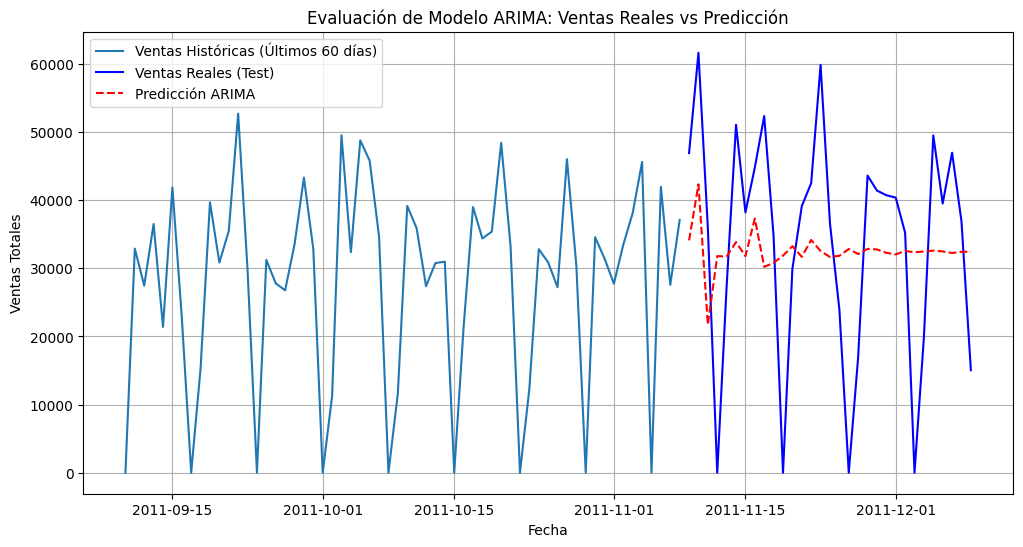

In [6]:
# Generamos una visualización de los datos reales y preditivos
plt.figure(figsize=(12, 6))
plt.plot(train_df.index[-60:], y_train[-60:], label='Ventas Históricas (Últimos 60 días)')
plt.plot(test_df.index, y_test, label='Ventas Reales (Test)', color='blue')
plt.plot(test_df.index, test_df['Predictions_ARIMA'], label='Predicción ARIMA', color='red', linestyle='--')

plt.title('Evaluación de Modelo ARIMA: Ventas Reales vs Predicción')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.legend()
plt.grid(True)
plt.show()